# Загрузка датасета

In [ ]:
!uv pip install kaggle==1.6.17

Using Python 3.12.12 environment at: /usr
Resolved 13 packages in 505ms
Prepared 1 package in 130ms
Uninstalled 1 package in 3ms
Installed 1 package in 1ms
 - kaggle==1.7.4.5
 + kaggle==1.6.17


In [ ]:
# загрузка датасета
!kaggle datasets download -d akhatova/pcb-defects

/usr/local/lib/python3.12/dist-packages/kaggle/api_client.py:244: SyntaxWarning: invalid escape sequence '\['
  sub_kls = re.match('list\[(.*)\]', klass).group(1)
/usr/local/lib/python3.12/dist-packages/kaggle/api_client.py:249: SyntaxWarning: invalid escape sequence '\('
  sub_kls = re.match('dict\(([^,]*), (.*)\)', klass).group(2)
/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api.py:1055: SyntaxWarning: invalid escape sequence '\&'
  """Creates (aka \&quot;drops\&quot;) a new file into the inbox.  # noqa: E501
/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api.py:1076: SyntaxWarning: invalid escape sequence '\&'
  """Creates (aka \&quot;drops\&quot;) a new file into the inbox.  # noqa: E501
Dataset URL: https://www.kaggle.com/datasets/akhatova/pcb-defects
License(s): unknown
100% 1.87G/1.88G [00:48<00:00, 41.5MB/s]
100% 1.88G/1.88G [00:48<00:00, 41.2MB/s]


In [ ]:
# распаковка архива датасета
!unzip /content/pcb-defects.zip

Archive:  /content/pcb-defects.zip
  inflating: PCB_DATASET/Annotations/Missing_hole/01_missing_hole_01.xml  
  inflating: PCB_DATASET/Annotations/Missing_hole/01_missing_hole_02.xml  
  inflating: PCB_DATASET/Annotations/Missing_hole/01_missing_hole_03.xml  
  inflating: PCB_DATASET/Annotations/Missing_hole/01_missing_hole_04.xml  
  inflating: PCB_DATASET/Annotations/Missing_hole/01_missing_hole_05.xml  
  inflating: PCB_DATASET/Annotations/Missing_hole/01_missing_hole_06.xml  
  inflating: PCB_DATASET/Annotations/Missing_hole/01_missing_hole_07.xml  
  inflating: PCB_DATASET/Annotations/Missing_hole/01_missing_hole_08.xml  
  inflating: PCB_DATASET/Annotations/Missing_hole/01_missing_hole_09.xml  
  inflating: PCB_DATASET/Annotations/Missing_hole/01_missing_hole_10.xml  
  inflating: PCB_DATASET/Annotations/Missing_hole/01_missing_hole_11.xml  
  inflating: PCB_DATASET/Annotations/Missing_hole/01_missing_hole_12.xml  
  inflating: PCB_DATASET/Annotations/Missing_hole/01_missing_hole

# Импорт библиотек

In [ ]:
!pip install gradio

In [ ]:
import random
from tqdm import tqdm
import xml.etree.ElementTree as ET
import shutil

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Подготовка данных

In [ ]:
BASE_PATH = "/content/PCB_DATASET"
OUT_PATH = "/content/pcb_yolo"

classes = {
    "Missing_hole": 0,
    "Mouse_bite": 1,
    "Open_circuit": 2,
    "Short": 3,
    "Spur": 4,
    "Spurious_copper": 5
}

for split in ["train", "val"]: # Создаём папки для тренеровочной выборки изображений и валидационной
    os.makedirs(f"{OUT_PATH}/{split}/images", exist_ok=True)
    os.makedirs(f"{OUT_PATH}/{split}/labels", exist_ok=True)

def convert_bbox(w, h, xmin, ymin, xmax, ymax): # Функция конвертации координат из Pascal VOC в YOLO формат
    x = ((xmin + xmax) / 2) / w
    y = ((ymin + ymax) / 2) / h
    bw = (xmax - xmin) / w
    bh = (ymax - ymin) / h
    return x, y, bw, bh

image_root = os.path.join(BASE_PATH, "images")
ann_root = os.path.join(BASE_PATH, "Annotations")

total_images = 0 # Счётчик обработанных изображений

for defect, cls_id in classes.items(): # Обрабатываем каждый класс дефектов
    img_dir = os.path.join(image_root, defect)
    ann_dir = os.path.join(ann_root, defect)

    images = [f for f in os.listdir(img_dir) if f.lower().endswith(".jpg")] # Получаем список JPG-изображений текущего класса
    random.shuffle(images) # Перемешиваем изображения

    split_idx = int(0.8 * len(images)) # Определяем количество тренеровочных изображений и валидационных

    for i, img_name in enumerate(tqdm(images, desc=defect)): # Обрабатываем каждое изображение с индикатором прогресса
        split = "train" if i < split_idx else "val"

        img_path = os.path.join(img_dir, img_name) # Полные пути к файлу изображения и аннотации
        xml_path = os.path.join(ann_dir, img_name.replace(".jpg", ".xml"))

        if not os.path.exists(xml_path):
            continue

        tree = ET.parse(xml_path) # Парсим XML-аннотацию
        root = tree.getroot()

        size = root.find("size") # Получаем размеры изображения из XML
        w = int(size.find("width").text)
        h = int(size.find("height").text)

        yolo_lines = []

        for obj in root.findall("object"): # Обрабатываем все объекты (дефекты) на изображении
            bnd = obj.find("bndbox")
            xmin = int(bnd.find("xmin").text)
            ymin = int(bnd.find("ymin").text)
            xmax = int(bnd.find("xmax").text)
            ymax = int(bnd.find("ymax").text)

            x, y, bw, bh = convert_bbox(w, h, xmin, ymin, xmax, ymax) # Конвертируем координаты в формат YOLO
            yolo_lines.append(f"{cls_id} {x} {y} {bw} {bh}")

        if not yolo_lines:
            continue

        label_path = f"{OUT_PATH}/{split}/labels/{img_name.replace('.jpg','.txt')}"
        with open(label_path, "w") as f:
            f.write("\n".join(yolo_lines)) # Сохраняем метки в файл

        shutil.copy(img_path, f"{OUT_PATH}/{split}/images/{img_name}") # Копируем изображение в целевую директорию
        total_images += 1

print(f"✅ Преобразование выполнено успешно |Изображения скопированы: {total_images}")

Spurious_copper: 100%|██████████| 116/116 [00:00<00:00, 2885.91it/s]

✅ Преобразование выполнено успешно |Изображения скопированы: 693


In [ ]:
print("Train images:", len(os.listdir("/content/pcb_yolo/train/images")))
print("Val images:", len(os.listdir("/content/pcb_yolo/val/images")))
print("Train labels:", len(os.listdir("/content/pcb_yolo/train/labels")))


Train images: 552
Val images: 141
Train labels: 552


# Обучение модели

In [ ]:

data_yaml = """
path: /content/pcb_yolo
train: train/images
val: val/images

names:
  0: Missing_hole
  1: Mouse_bite
  2: Open_circuit
  3: Short
  4: Spur
  5: Spurious_copper
"""

with open("/content/pcb_yolo/data.yaml", "w") as f:
    f.write(data_yaml)

print("✅ data.yaml created at /home/jovyan/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/pcb_yolo/data.yaml")

✅ data.yaml created at /home/jovyan/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/pcb_yolo/data.yaml


In [ ]:

model = YOLO('/content/yolov8m.pt')  # Загрузка предобученной модели
model.train(
    data='/content/pcb_yolo/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    project='/content/cvkk_8',
    name='pcb_defect_detection'
)


Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pcb_yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pcb_defect_detection, nbs=64, nms=False, opset=None, optimize=False, o

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79e5cb9083e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

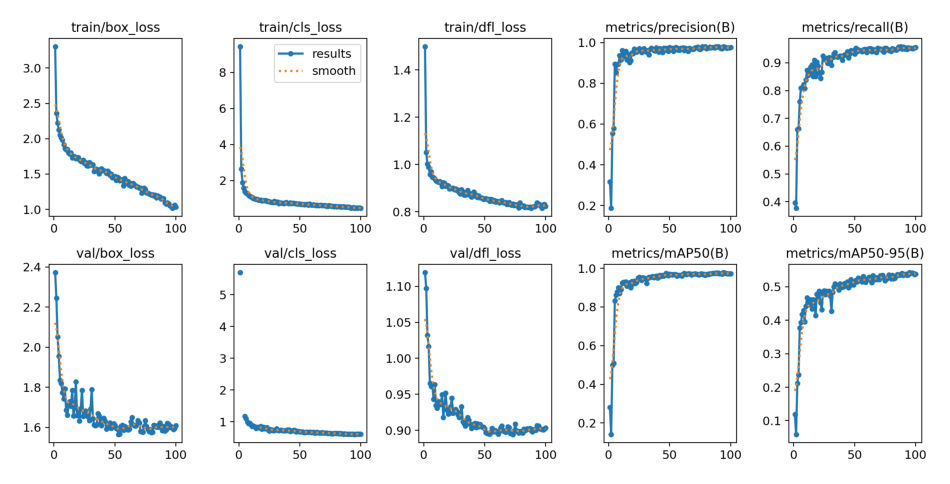

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

results_img = "/content/cvkk_8/pcb_defect_detection/results.png"

img = Image.open(results_img)
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")

(np.float64(-0.5), np.float64(2999.5), np.float64(2249.5), np.float64(-0.5))

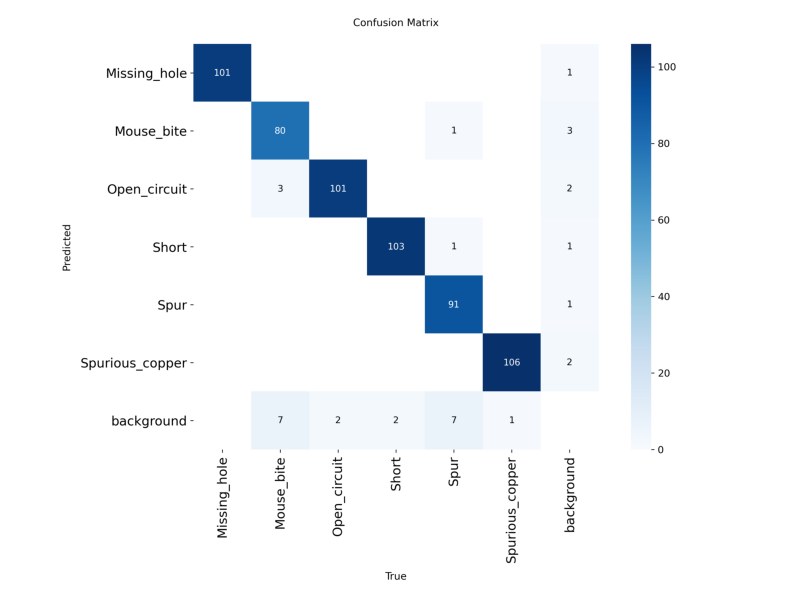

In [ ]:
cm_img = "/content/cvkk_8/pcb_defect_detection/confusion_matrix.png"

img = Image.open(cm_img)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")

# Итоговые результаты и метрики качества на Тестовой выборке

In [ ]:
model = YOLO("/content/cvkk_8/pcb_defect_detection/weights/best.pt")

model.predict(
    source="/content/pcb_yolo/val/images",
    conf=0.25,
    save=True
)


image 1/141 /content/pcb_yolo/val/images/01_missing_hole_12.jpg: 352x640 3 Missing_holes, 21.6ms
image 2/141 /content/pcb_yolo/val/images/01_mouse_bite_03.jpg: 352x640 1 Mouse_bite, 1 Open_circuit, 3.5ms
image 3/141 /content/pcb_yolo/val/images/01_mouse_bite_04.jpg: 352x640 3 Mouse_bites, 3.5ms
image 4/141 /content/pcb_yolo/val/images/01_mouse_bite_09.jpg: 352x640 2 Mouse_bites, 1 Open_circuit, 3.5ms
image 5/141 /content/pcb_yolo/val/images/01_mouse_bite_11.jpg: 352x640 2 Mouse_bites, 3.6ms
image 6/141 /content/pcb_yolo/val/images/01_mouse_bite_12.jpg: 352x640 2 Mouse_bites, 3.6ms
image 7/141 /content/pcb_yolo/val/images/01_mouse_bite_14.jpg: 352x640 1 Mouse_bite, 1 Open_circuit, 3.7ms
image 8/141 /content/pcb_yolo/val/images/01_mouse_bite_19.jpg: 352x640 1 Mouse_bite, 3.6ms
image 9/141 /content/pcb_yolo/val/images/01_open_circuit_01.jpg: 352x640 3 Open_circuits, 3.6ms
image 10/141 /content/pcb_yolo/val/images/01_open_circuit_18.jpg: 352x640 3 Open_circuits, 3.6ms
image 11/141 /conten

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Missing_hole', 1: 'Mouse_bite', 2: 'Open_circuit', 3: 'Short', 4: 'Spur', 5: 'Spurious_copper'}
 obb: None
 orig_img: array([[[139, 138, 147],
         [137, 136, 145],
         [134, 133, 142],
         ...,
         [155, 151, 157],
         [151, 147, 153],
         [154, 150, 156]],
 
        [[138, 137, 147],
         [138, 137, 147],
         [135, 134, 143],
         ...,
         [153, 149, 155],
         [150, 146, 152],
         [153, 149, 155]],
 
        [[139, 138, 148],
         [142, 141, 151],
         [142, 141, 151],
         ...,
         [152, 148, 154],
         [150, 146, 152],
         [152, 148, 154]],
 
        ...,
 
        [[138, 134, 140],
         [144, 140, 146],
         [141, 137, 143],
         ...,
         [153, 146, 151],
         [152, 146, 151],
         [155, 149, 154]],
 
        [[145, 139, 144

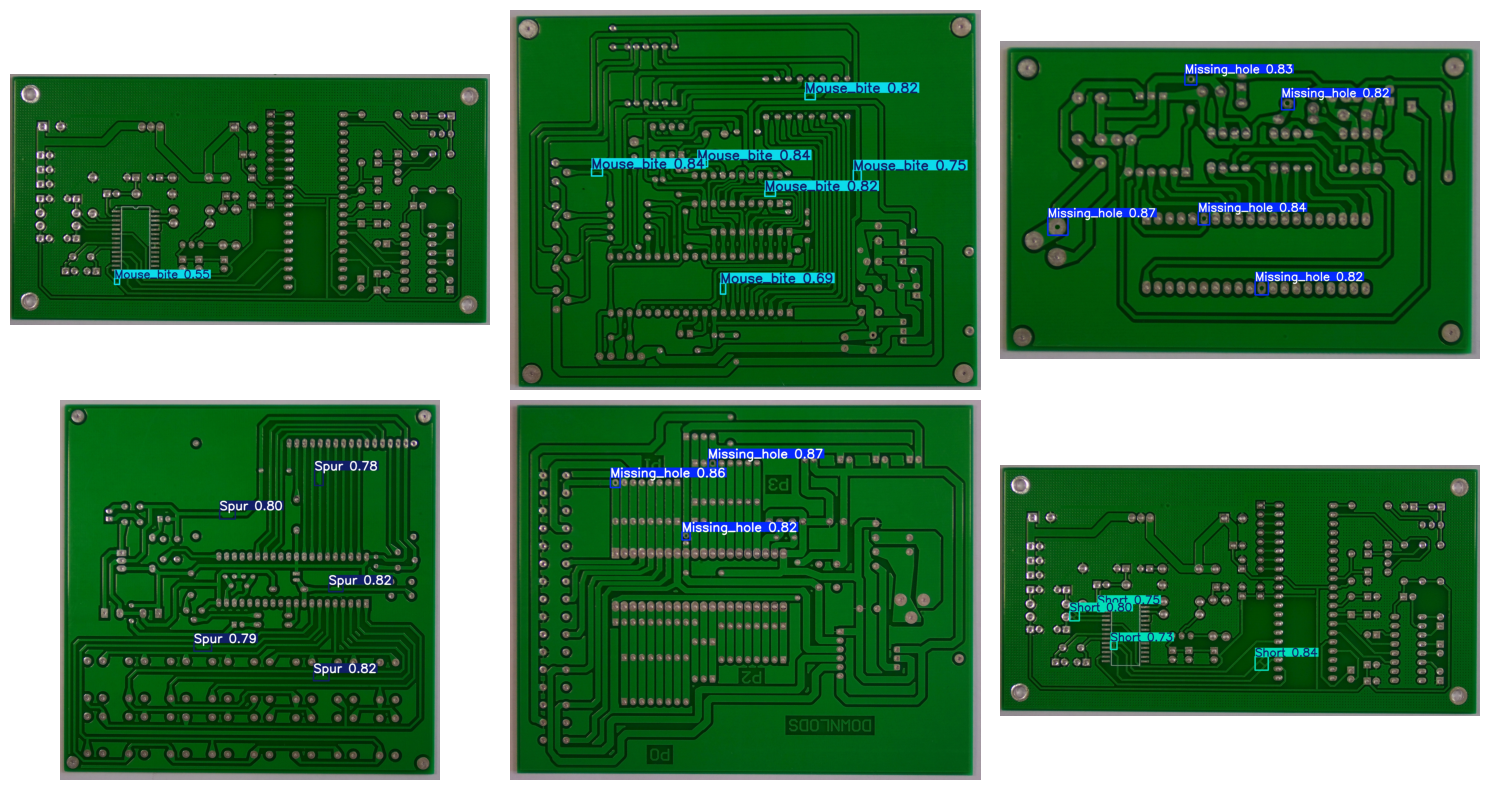

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

pred_dir = "/content/runs/detect/predict"

images = os.listdir(pred_dir) # Получение списка файлов в папке

plt.figure(figsize=(15, 8))
for i, img_name in enumerate(images[:6]):
    img = Image.open(os.path.join(pred_dir, img_name))
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()

*   open_circuit (обрыв цепи);
*   short (короткое замыкание);
*   spurious_copper (лишняя медь);
*   missing_hole (отсутствие отверстия);
*   mouse_bite (повреждения от «мышиных укусов»);
*   spur (выступы)



Весь код который описан выше мне он нужен для получения одного файла best.pt - это веса всех слоёв модели с помощью которых он делает чёткие предсказания

# Функции

## Отчёт

In [ ]:
model = YOLO('best_8m.pt')
results = model.predict( # Предсказание дефектов
            source='/content/01_short_19.jpg',
            conf=0.25,
            save=True,
            project="content/preict_itog",
            name="results",
            exist_ok=True
        )


image 1/1 /content/01_short_19.jpg: 352x640 4 Shorts, 25.6ms
Speed: 2.3ms preprocess, 25.6ms inference, 1.3ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /content/runs/detect/content/preict_itog/results


In [ ]:
model.names

{0: 'Missing_hole',
 1: 'Mouse_bite',
 2: 'Open_circuit',
 3: 'Short',
 4: 'Spur',
 5: 'Spurious_copper'}

In [ ]:
model.names[5]

'Spurious_copper'

In [ ]:
results[0].boxes.cls.cpu().numpy()

array([          3,           3,           3,           3], dtype=float32)

In [ ]:
# Количество обнаруженных объектов
print(f"Найдено объектов: {len(results[0].boxes)}")

# Классы всех обнаруженных объектов (в виде индексов)
print("Индексы классов:", results[0].boxes.cls.cpu().numpy())

# Уровни достоверности (confidence) для каждого обнаружения
print("Уровни достоверности:", results[0].boxes.conf.cpu().numpy())

Найдено объектов: 4
Индексы классов: [          3           3           3           3]
Уровни достоверности: [    0.86191     0.85676     0.84067     0.75289]


In [ ]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([3., 3., 3., 3.], device='cuda:0')
conf: tensor([0.8619, 0.8568, 0.8407, 0.7529], device='cuda:0')
data: tensor([[8.2003e+02, 1.3143e+03, 8.7334e+02, 1.3697e+03, 8.6191e-01, 3.0000e+00],
        [8.1256e+02, 1.1630e+03, 8.7461e+02, 1.2208e+03, 8.5676e-01, 3.0000e+00],
        [1.9819e+03, 1.1994e+03, 2.0525e+03, 1.2589e+03, 8.4067e-01, 3.0000e+00],
        [6.1607e+02, 8.7839e+02, 6.5728e+02, 9.2664e+02, 7.5289e-01, 3.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (1586, 3034)
shape: torch.Size([4, 6])
xywh: tensor([[ 846.6863, 1341.9965,   53.3088,   55.3950],
        [ 843.5834, 1191.8953,   62.0451,   57.7552],
        [2017.1926, 1229.1729,   70.5331,   59.4471],
        [ 636.6743,  902.5140,   41.2053,   48.2579]], device='cuda:0')
xywhn: tensor([[0.2791, 0.8462, 0.0176, 0.0349],
        [0.2780, 0.7515, 0.0204, 0.0364],
        [0.6649, 0.7750, 0.0232, 0.0375],
        [0.2098, 0.5691, 0.013

In [ ]:
arr = [0, 0, 0, 0, 0, 0]
detect = results[0].boxes.cls.cpu().numpy()
for i in range(len(detect)):
     arr[int(detect[i])] += 1

In [ ]:
arr

[0, 0, 0, 4, 0, 0]

In [ ]:
def table(results):
    arr = [0, 0, 0, 0, 0, 0]
    detect = results[0].boxes.cls.cpu().numpy()
    for i in range(len(detect)):
        arr[int(detect[i])] += 1
    return arr

In [ ]:
# Исходный DataFrame
df = pd.DataFrame({
    'Missing_hole': [],
    'Mouse_bite': [],
    'Open_circuit': [],
    'Short': [],
    'Spur': [],
    'Spurious_copper': [],
})

In [ ]:
# Добавление новой строки
df.loc[len(df)] = table(results)
print(df)

   Missing_hole  Mouse_bite  Open_circuit  Short  Spur  Spurious_copper
0             0           0             0      4     0                0


# Итоговый проект

In [ ]:
import gradio as gr
from ultralytics import YOLO
import pandas as pd

model = YOLO('best_8m.pt')


# DataFrame для сбора данных
df = pd.DataFrame({
    'Missing_hole': [],
    'Mouse_bite': [],
    'Open_circuit': [],
    'Short': [],
    'Spur': [],
    'Spurious_copper': [],
})

def table(results):
    arr = [0, 0, 0, 0, 0, 0]
    detect = results[0].boxes.cls.cpu().numpy() # Извлекаем классы обнаруженных объектов
    for i in range(len(detect)): # Проходим циклом по найденым дефектом и увеличиваем определённое место в списке
        arr[int(detect[i])] += 1
    return arr

def detect_objects_in_video(frame):
    if frame is None:
        return None
    # Запускаем инференцию YOLO
    results = model(frame, stream=False)
    # Получаем аннотированный кадр
    for r in results:
        annotated_frame = r.plot()

    return annotated_frame


# Функция для обработки изображения
def process_image(img):
    result = model.predict( # Предсказание дефектов
            source=img,
            conf=0.25,
            save=True,
            project="content/preict_itog",
            name="results",
            exist_ok=True
        )
    print(result)
    # Добавление новой строки
    df.loc[len(df)] = table(result)
    print(df)
    return result[0].plot()

with gr.Blocks() as calculator_page:
    gr.Markdown("# Ручной способ")
    with gr.Row():
        with gr.Column():
            # Поле для загрузки изображений
            input_img = gr.Image(
                label="Загрузите изображение",
                type="numpy"
            )
            # Кнопка для запуска обработки
            submit_btn = gr.Button("Обработать изображение", variant="primary")

        with gr.Column():
            output_img = gr.Image(label="Результат") # Поле для вывода результата

    # Связываем кнопку с функцией
    submit_btn.click(
        fn=process_image,
        inputs=input_img,
        outputs=output_img
    )

def new_table():
    return df

with gr.Blocks() as podrobno:
    gr.Markdown("# Отчёт")
    report_table = gr.DataFrame(label="Статистика дефектов", value=df)  # Инициализируем таблицу
    refresh_btn = gr.Button("Обновить отчёт") # Кнопка для обновления таблицы
    refresh_btn.click( # Связываем кнопку с функцией для обновления таблицы
        fn=new_table,
        inputs=[],
        outputs=report_table
    )

with gr.Blocks() as text_converter_page:
    with gr.Blocks(title="YOLOv8 Live Object Detection") as demo:
        gr.Markdown("# Детекция объектов в реальном времени с YOLOv8")
        gr.Markdown("Наведите камеру на объекты — модель YOLOv8 будет детектировать их в реальном времени.")

        with gr.Row():
            # Входной компонент — веб‑камера
            webcam_input = gr.Image(
                label="Видеопоток с веб‑камеры",
                type="numpy",
                streaming=True  # Включаем режим потоковой передачи
            )

            # Выходной компонент — результат детекции
            output_image = gr.Image(
                label="Результат детекции",
                type="numpy"
            )

        # Обработчик для live‑детекции
        webcam_input.stream(
            fn=detect_objects_in_video,
            inputs=webcam_input,
            outputs=output_image,
            time_limit=600,
            show_progress=False
        )

        gr.Markdown("**Инструкция:**\n1. Разрешите доступ к камере.\n2. Наведите камеру на объекты.\n3. Наблюдайте за детекцией в реальном времени.\n4. Нажмите 'Stop' для остановки.")



with gr.Blocks() as random_generator_page:
    gr.Markdown("# Учебный проект СВКК(Система визуального контроля качества)")
    gr.Markdown("## Анотация проетка")
    gr.Markdown("""Проект по разработке автоматизированной системы визуального контроля качества (СВКК) на базе нейросетевых технологий, которая позволит полностью заменить ручной визуальный контроль на производственной линии.

Название проекта: Разработка автоматизированной системы визуального контроля качества (СВКК) на базе нейросетевых технологий.

Цель проекта: Полная замена ручного визуального контроля на производственной линии посредством внедрения автоматизированной системы.

Ключевые преимущества готового решения:
-Высокоскоростной контроль: проверка изделий осуществляется в режиме реального времени, не замедляя производственный процесс.
-Повышенная точность: система демонстрирует более высокую эффективность в выявлении дефектов по сравнению с ручным контролем.
-Объективность оценки: результаты не зависят от субъективного мнения оператора или его усталости.
-Полная прослеживаемость: все выявленные дефекты автоматически фиксируются и привязываются к конкретному изделию, формируя подробный отчёт.
Результаты реализации:
В рамках проекта успешно разработана и внедрена СВКК, базирующаяся на нейросетевых алгоритмах. Система полностью соответствует заявленным целям и задачам.

Технологическое преимущество:
Разработанная модель не использует примитивное сравнение с эталонным образцом. Вместо этого она выполняет прямую детекцию дефектов (объектов) на изображении. Данный подход обеспечивает универсальность применения — система совместима с широким спектром типов печатных плат без необходимости глубокой перенастройки.""")
    gr.Markdown("## Инструкция по использованию")
    gr.Markdown("Для использования проекта необходимо загрузить изображение и нажать кнопку 'Обработать изображение'. Результат будет выведен в окне 'Результат'")

# Объединение страниц во вкладках
demo = gr.TabbedInterface(
    [calculator_page, text_converter_page, podrobno, random_generator_page],
    ["Ручной", "Через web-камеру", "Отчёт" ,"Подробности"]
).launch(debug=True)

if __name__ == "__main__":
    demo.launch(share=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d535f159a898bc813b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


KeyboardInterrupt: 

# **GIT https://github.com/epkulakov/cvkk/tree/master**